In [2]:
import pandas as pd

In [3]:
file_path="C:/Users/KIIT0001/OneDrive/Desktop/Spotify project/SpotifyFeatures.csv"
df=pd.read_csv(file_path)

In [4]:
df.info(),df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

(None,
    genre        artist_name                        track_name  \
 0  Movie     Henri Salvador       C'est beau de faire un Show   
 1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
 2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
 3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
 4  Movie       Fabien Nataf                         Ouverture   
 
                  track_id  popularity  acousticness  danceability  \
 0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
 1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
 2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
 3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
 4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   
 
    duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
 0        99373   0.910             0.000  C#    0.3460    -1.828  Major   
 1       137373   0.7

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
df.drop(columns=["artist_name","track_name","track_id"],inplace=True)

In [7]:
label_encoder=LabelEncoder()
df["genre"]=label_encoder.fit_transform(df["genre"])

In [8]:
categorical_cols=df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode: ",categorical_cols)

Categorical columns to encode:  ['key', 'mode', 'time_signature']


In [9]:
df=pd.get_dummies(df,columns=categorical_cols,drop_first=True)

In [10]:
X=df.drop("genre",axis=1)
y=df["genre"]

In [11]:
print("Remaining object columns:",X.select_dtypes(include='object').columns.tolist())

Remaining object columns: []


In [12]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((186180, 27), (46545, 27), (186180,), (46545,))

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [15]:
model=LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred=model.predict(X_test)

In [17]:
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

Accuracy:  0.3864647115694489

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.22      0.17      0.19      1853
           2       0.41      0.34      0.37      1787
           3       0.33      0.24      0.28      1805
           4       0.67      0.73      0.70      1081
           5       0.21      0.13      0.16      1871
           6       0.51      0.47      0.49      1851
           7       0.94      0.93      0.94      1936
           8       0.27      0.42      0.33      1733
           9       0.19      0.17      0.18      1740
          10       0.45      0.48      0.47      1875
          11       0.26      0.29      0.27      1860
          12       0.31      0.37      0.34      1859
          13       0.20      0.12      0.15      1909
          14       0.35      0.28      0.31      1888
          15       0.47      0.39      0.42      1561
          16       0.62   

C:\Users\KIIT0001\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KIIT0001\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KIIT0001\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score

In [19]:
rf=RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

In [20]:
print("RF Accuracy: ",accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

RF Accuracy:  0.3689762595337845
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.11      0.08      0.10      1853
           2       0.61      0.56      0.58      1787
           3       0.38      0.39      0.39      1805
           4       0.76      0.76      0.76      1081
           5       0.02      0.02      0.02      1871
           6       0.63      0.61      0.62      1851
           7       0.97      0.94      0.95      1936
           8       0.38      0.43      0.41      1733
           9       0.10      0.10      0.10      1740
          10       0.52      0.54      0.53      1875
          11       0.19      0.20      0.20      1860
          12       0.13      0.15      0.14      1859
          13       0.05      0.04      0.05      1909
          14       0.36      0.34      0.35      1888
          15       0.58      0.54      0.56      1561
          16       0.74      0.88      0.80     

C:\Users\KIIT0001\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KIIT0001\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KIIT0001\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,classification_report

In [22]:
mlp=MLPClassifier(hidden_layer_sizes=(256,128,64),activation='relu',max_iter=500,early_stopping=True,random_state=42)
mlp.fit(X_train,y_train)

,hidden_layer_sizes,"(256, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [23]:
y_pred_mlp=mlp.predict(X_test)

In [24]:
print("MLP Accuracy: ",accuracy_score(y_test,y_pred_mlp))
print(classification_report(y_test,y_pred_mlp))

MLP Accuracy:  0.4429691696207971
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.29      0.19      0.23      1853
           2       0.56      0.62      0.59      1787
           3       0.44      0.39      0.41      1805
           4       0.70      0.78      0.74      1081
           5       0.24      0.06      0.10      1871
           6       0.62      0.59      0.60      1851
           7       0.95      0.94      0.95      1936
           8       0.39      0.44      0.41      1733
           9       0.23      0.16      0.19      1740
          10       0.53      0.56      0.55      1875
          11       0.26      0.40      0.32      1860
          12       0.31      0.40      0.35      1859
          13       0.22      0.15      0.17      1909
          14       0.43      0.36      0.39      1888
          15       0.58      0.46      0.52      1561
          16       0.73      0.86      0.79    

C:\Users\KIIT0001\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KIIT0001\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KIIT0001\tf-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
import tensorflow as tf
print(tf.__version__)

2.15.0


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)

In [27]:
import tensorflow as tf
from tensorflow.keras import models,layers
model=models.Sequential([
    layers.Dense(256,activation='relu',input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(27,activation='softmax')])

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [29]:
callback=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

In [35]:
history=model.fit(
    X_train,y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[callback],
    verbose=1)

Epoch 1/50


1164/1164 [==============================] - 17s 11ms/step - loss: 2.4001 - accuracy: 0.2604 - val_loss: 1.9403 - val_accuracy: 0.3768
Epoch 2/50
1164/1164 [==============================] - 12s 11ms/step - loss: 2.0556 - accuracy: 0.3411 - val_loss: 1.8578 - val_accuracy: 0.3952
Epoch 3/50
1164/1164 [==============================] - 13s 11ms/step - loss: 1.9773 - accuracy: 0.3624 - val_loss: 1.8194 - val_accuracy: 0.4025
Epoch 4/50
1164/1164 [==============================] - 12s 11ms/step - loss: 1.9381 - accuracy: 0.3724 - val_loss: 1.7966 - val_accuracy: 0.4091
Epoch 5/50
1164/1164 [==============================] - 12s 11ms/step - loss: 1.9091 - accuracy: 0.3819 - val_loss: 1.7790 - val_accuracy: 0.4135
Epoch 6/50
1164/1164 [==============================] - 12s 11ms/step - loss: 1.8862 - accuracy: 0.3886 - val_loss: 1.7545 - val_accuracy: 0.4196
Epoch 7/50
1164/1164 [==============================] - 12s 11ms/step - loss: 1.8668 - accuracy: 0.3928 - val_loss: 1.7494

In [36]:
test_loss,test_acc=model.evaluate(X_test,y_test,verbose=1)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

1455/1455 [==============================] - 6s 4ms/step - loss: 1.6573 - accuracy: 0.4482
Test accuracy: 0.4482
Test loss: 1.6573


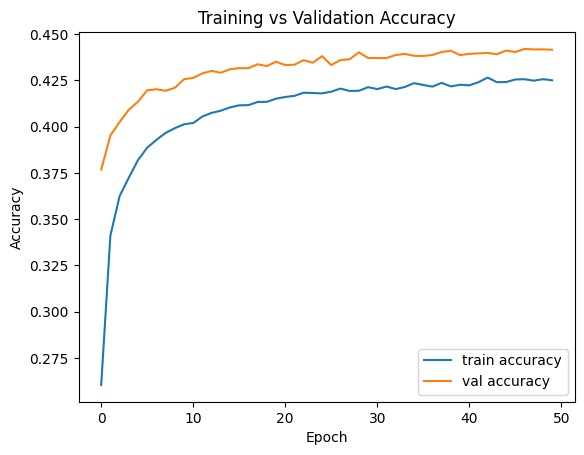

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


In [47]:
# Save Your Trained Model - Run This in Your Notebook First

# After training your TensorFlow model (the one with 44.8% accuracy), run this code:

import joblib

# Save your trained TensorFlow model
model.save('spotify_model.h5')

# Save your scaler (the StandardScaler you used)
joblib.dump(scaler, 'scaler.pkl')

# Save your label encoder (for the genres)
joblib.dump(label_encoder, 'label_encoder.pkl')

print("✅ Model and preprocessors saved successfully!")
print("Files created:")
print("- spotify_model.h5")
print("- scaler.pkl") 
print("- label_encoder.pkl")
print("\nNow you can run the Streamlit app!")

# To run the Streamlit app, use this command in terminal:
# streamlit run spotify-streamlit-app.py

✅ Model and preprocessors saved successfully!
Files created:
- spotify_model.h5
- scaler.pkl
- label_encoder.pkl

Now you can run the Streamlit app!
